In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/ProjectCapstone/DATA")

RESULT_DIR = BASE_DIR / f"results_instructblip_500"
dir_500 = RESULT_DIR

RESULT_DIR = BASE_DIR / f"results_instructblip_2000"
dir_2000 = RESULT_DIR



In [ ]:
report_500 = pd.read_csv(dir_500 / "report_table_final.csv")
report_2000 = pd.read_csv(dir_2000 / "report_table_final.csv")

print(report_500.head())
print(report_2000.head())

                        Model  CLIPScore  BLEU-4   CIDEr   SPICE
0                    Baseline     0.2900  0.1467  0.5320  0.1713
1   Retrieval-Augmented (k=1)     0.2624  0.1030  0.3650  0.1241
2   Retrieval-Augmented (k=3)     0.2625  0.1362  0.4316  0.1229
3   Retrieval-Augmented (k=5)     0.2633  0.1194  0.3725  0.1262
4  Retrieval-Augmented (k=10)     0.2556  0.1187  0.3838  0.1013
                        Model  CLIPScore  BLEU-4   CIDEr   SPICE
0                    Baseline     0.2900  0.1467  0.5320  0.1713
1   Retrieval-Augmented (k=1)     0.2682  0.1026  0.3983  0.1265
2   Retrieval-Augmented (k=3)     0.2748  0.1265  0.4745  0.1370
3   Retrieval-Augmented (k=5)     0.2719  0.1157  0.4229  0.1189
4  Retrieval-Augmented (k=10)     0.2788  0.1471  0.4660  0.1478


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric(metric):
    labels = report_500["Model"].tolist()
    report_2000_aligned = report_2000.set_index("Model").loc[labels].reset_index()

    vals_500 = report_500[metric].tolist()
    vals_2000 = report_2000_aligned[metric].tolist()

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, vals_500, width, label="500")
    plt.bar(x + width/2, vals_2000, width, label="2000")

    plt.xticks(x, labels, rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric}: 500 vs 2000")
    plt.legend()
    plt.tight_layout()
    plt.show()

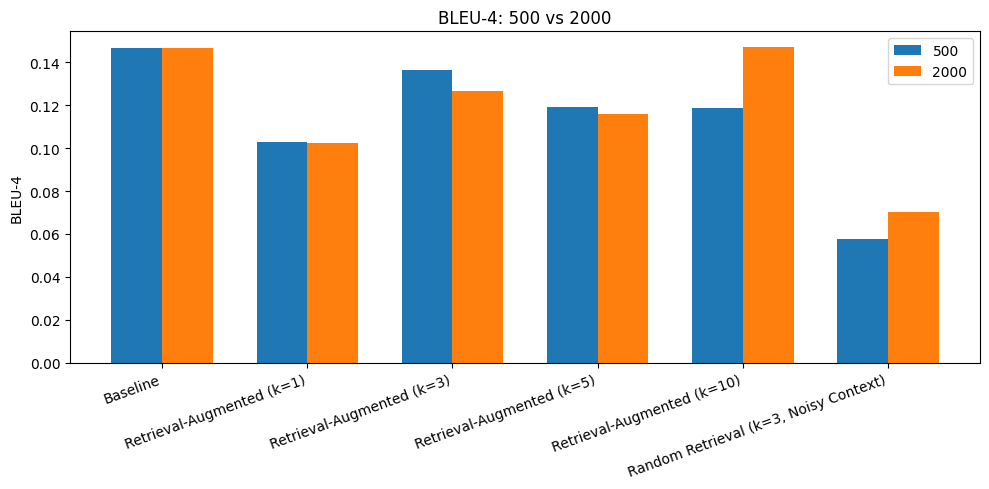

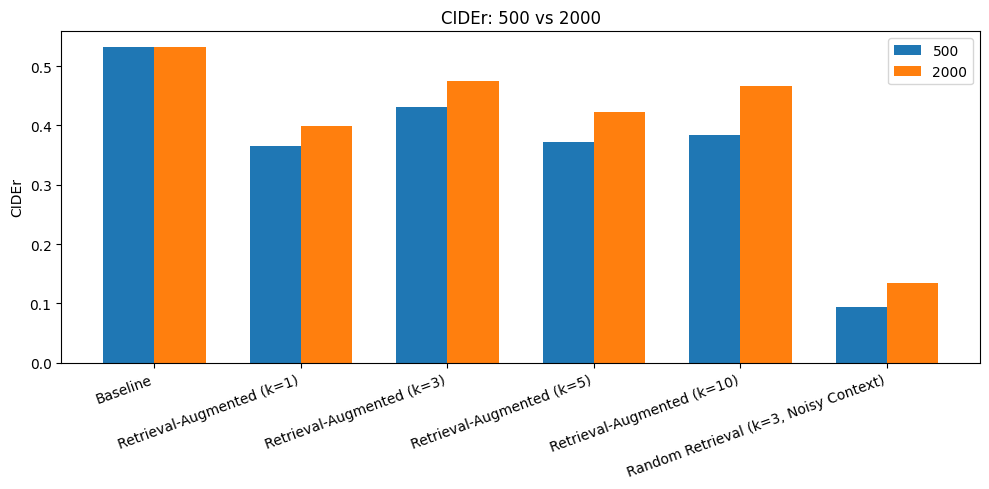

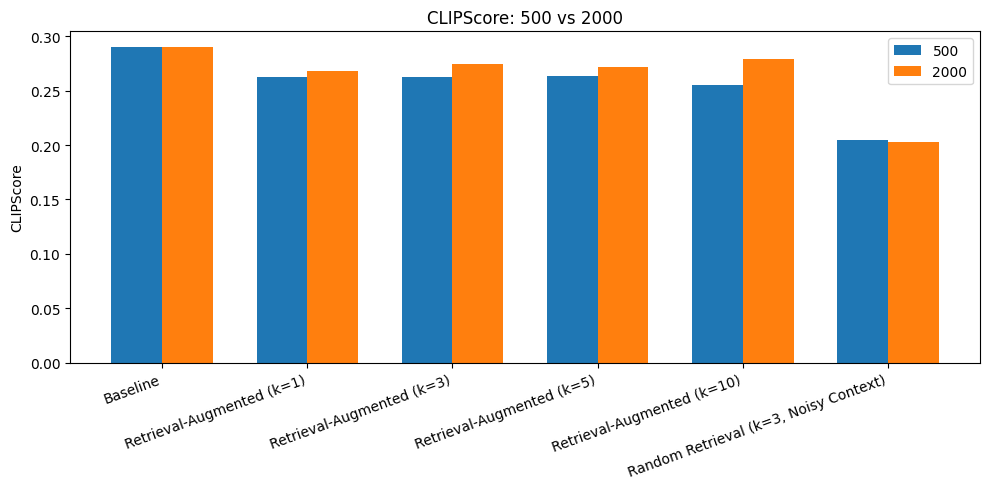

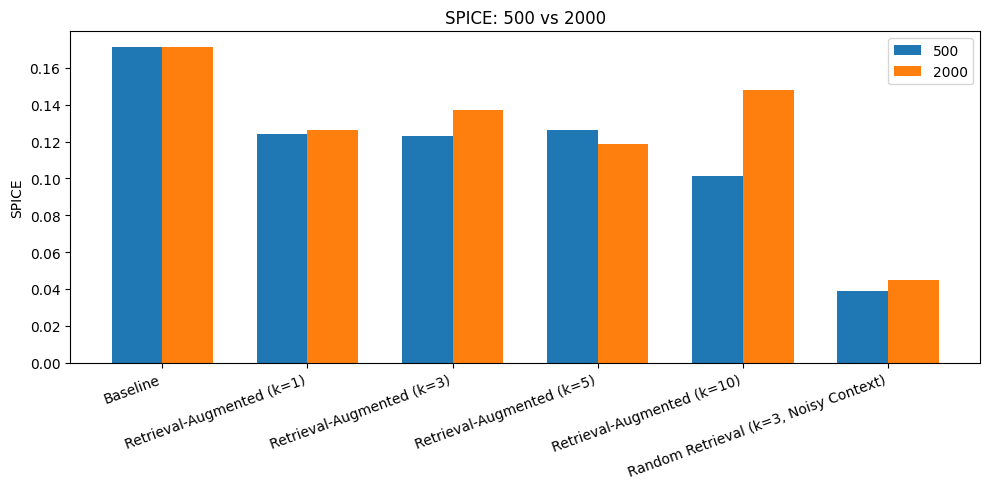

In [ ]:
plot_metric("BLEU-4")
plot_metric("CIDEr")
plot_metric("CLIPScore")
plot_metric("SPICE")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_2x2_random_vs_selective():
    metrics = ["BLEU-4", "CIDEr", "CLIPScore", "SPICE"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Extract values
        selective_500 = report_500.loc[
            report_500["Model"] == "Retrieval-Augmented (k=3)", metric
        ].values[0]

        random_500 = report_500.loc[
            report_500["Model"] == "Random Retrieval (k=3, Noisy Context)", metric
        ].values[0]

        selective_2000 = report_2000.loc[
            report_2000["Model"] == "Retrieval-Augmented (k=3)", metric
        ].values[0]

        random_2000 = report_2000.loc[
            report_2000["Model"] == "Random Retrieval (k=3, Noisy Context)", metric
        ].values[0]

        # Arrange values
        vals_selective = [selective_500, selective_2000]
        vals_random = [random_500, random_2000]

        x = np.arange(2)  # 500, 2000
        width = 0.35

        # Bars
        bars1 = ax.bar(x - width/2, vals_selective, width, label="Selective (k=3)")
        bars2 = ax.bar(x + width/2, vals_random, width, label="Random (k=3)")

        # Labels and title
        ax.set_xticks(x)
        ax.set_xticklabels(["500", "2000"])
        ax.set_title(metric)
        ax.set_ylabel(metric)

        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f"{height:.3f}", ha='center', va='bottom', fontsize=8)

        for bar in bars2:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f"{height:.3f}", ha='center', va='bottom', fontsize=8)

    # Shared legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2)

    # Title
    fig.suptitle("Selective vs Random Retrieval (k=3) Across Metrics", fontsize=14)

    # Layout adjustment
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    plt.show()

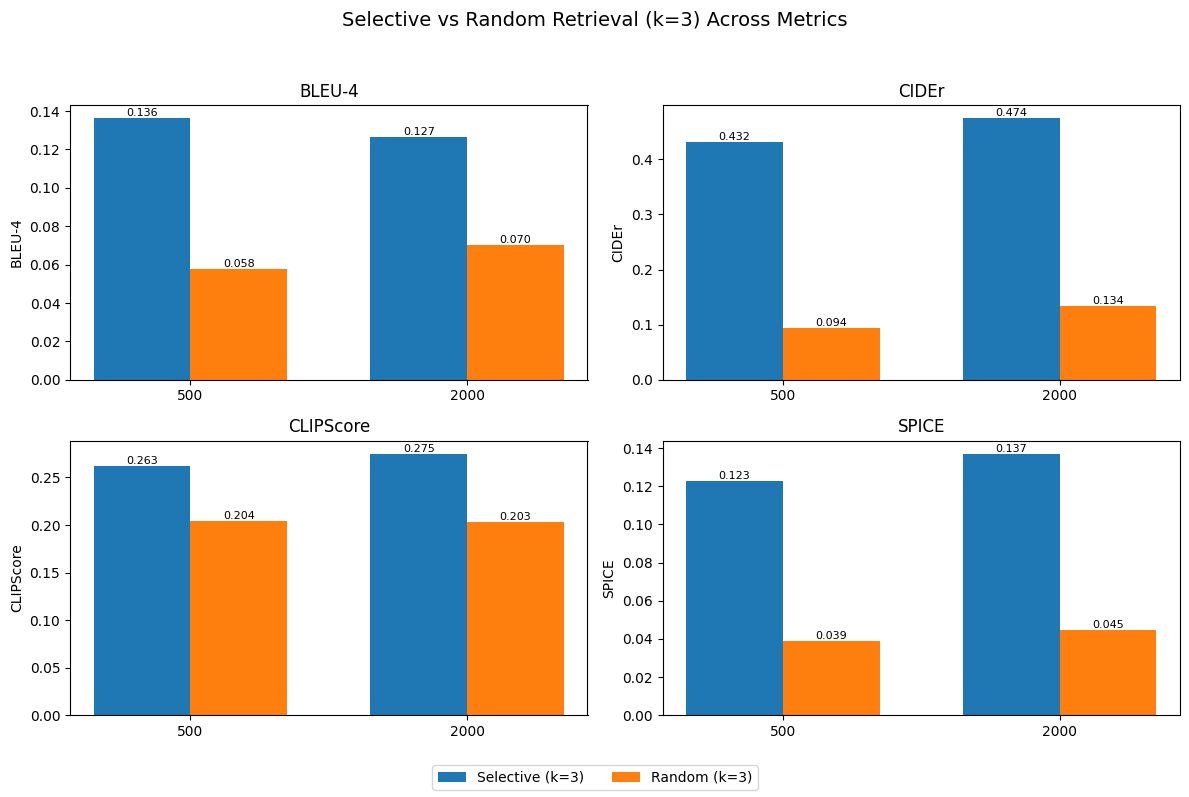

In [ ]:
plot_2x2_random_vs_selective()